# Analise exploratoria — Spotify Tracks Dataset

Este notebook concentra em um so lugar os processos de analise de dados do
repositorio (hoje espalhados em scripts `.py` na raiz): perfil do dataset,
agregacoes por genero/artista/album e as visualizacoes usadas no
[dashboard do site](https://lucas-av.github.io/Grupo-8-ResIA/).

Os scripts (`profile_dataset.py`, `group_occurrences.py`,
`plot_genre_charts.py`, `plot_genre_mode.py`,
`plot_popularity_occurrences.py`, `plot_correlations.py`) continuam sendo a
forma reprodutivel de gerar os artefatos versionados (PNGs/CSVs usados pelo
site) — ver `README.md` > Como reproduzir. Este notebook e para exploracao
interativa: mesma logica, saida inline, sem escrever arquivo nenhum.

## Scripts do pipeline

Cada secao abaixo reimplementa a logica de um script `.py` da raiz do
repositorio. Os scripts continuam sendo a forma reprodutivel de gerar os
artefatos versionados (rodados via `README.md` > Como reproduzir / CI); esta
tabela documenta o que cada um faz para quem esta navegando o notebook.

| Script | O que faz |
|---|---|
| `chart_style.py` | Constantes de cor/tamanho e `apply_style()` — visual compartilhado por todos os graficos matplotlib do repo. |
| `group_occurrences.py` | Agrupa `dataset.csv` por coluna (contagem de valores) e por `track_genre` (contagem + medias numericas); gera `occurrences_by_column.csv` e `occurrences_by_genre.csv`. |
| `profile_dataset.py` | Perfil geral do dataset (total de faixas, unicidade, nulos), distribuicao de faixas por artista/album em buckets, e lista de faixas presentes em mais de um genero; gera `dataset_profile.json`, `artist_track_distribution.png`, `album_track_distribution.png`, `dataset_multi_genre_tracks.csv`. |
| `plot_genre_charts.py` | A partir de `occurrences_by_genre.csv`, gera `genre_popularity.png` (barras de popularidade media por genero) e `genre_energy_dance.png` (dispersao energia x dancabilidade, com `adjustText` para separar rotulos). |
| `plot_genre_mode.py` | Proporcao de faixas em escala maior (mode 1) vs. menor (mode 0) por genero; gera `genre_mode.png`. |
| `plot_popularity_occurrences.py` | Popularidade media das faixas em funcao de quantas faixas o artista tem na base (buckets de ocorrencia); gera `popularity_occurrences.png`. |
| `plot_correlations.py` | Matriz de correlacao (Pearson) entre popularidade, duracao e features de audio continuas; gera `correlation_heatmap.png` e `correlations_top_pairs.csv`. |
| `site/build_site.py` | Le os CSVs/JSON/PNGs gerados pelos scripts acima e renderiza (via Jinja2) o dashboard estatico em `site/dist/` publicado no GitHub Pages. |

In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

from chart_style import ACCENT, GRID, INK, INK_SECONDARY, LABEL_SIZE, TICK_SIZE, TITLE_SIZE, apply_style

DATA_FILE = "data/processed/dataset.csv"
pd.set_option("display.max_columns", None)

## 1. Carregar o dataset

`dataset.csv`: faixas do Spotify com metadados (artista, album, genero) e
features de audio (danceability, energy, valence, ...).

In [2]:
df = pd.read_csv(DATA_FILE)
print(df.shape)
df.head()

(31819, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Perfil geral do dataset

Contagem de linhas, unicidade de `track_id`, duplicatas e nulos por coluna
— mesma logica de `profile_dataset.py::compute_profile`.

In [3]:
def compute_profile(df: pd.DataFrame) -> dict:
    total_tracks = len(df)
    unique_track_ids = int(df["track_id"].nunique())
    null_counts = {col: int(n) for col, n in df.isna().sum().items() if n > 0}
    return {
        "total_tracks": total_tracks,
        "unique_track_ids": unique_track_ids,
        "duplicate_rows": total_tracks - unique_track_ids,
        "unique_artists": int(df["artists"].nunique()),
        "unique_albums": int(df["album_name"].nunique()),
        "unique_genres": int(df["track_genre"].nunique()),
        "null_counts": null_counts,
    }

profile = compute_profile(df)
profile

{'total_tracks': 31819,
 'unique_track_ids': 28888,
 'duplicate_rows': 2931,
 'unique_artists': 10872,
 'unique_albums': 15481,
 'unique_genres': 32,
 'null_counts': {}}

## 3. Faixas por artista e por album (distribuicao)

Quantos artistas/albuns tem 1 faixa, 2, 3, ... na base — mesmos buckets de
`profile_dataset.py`.

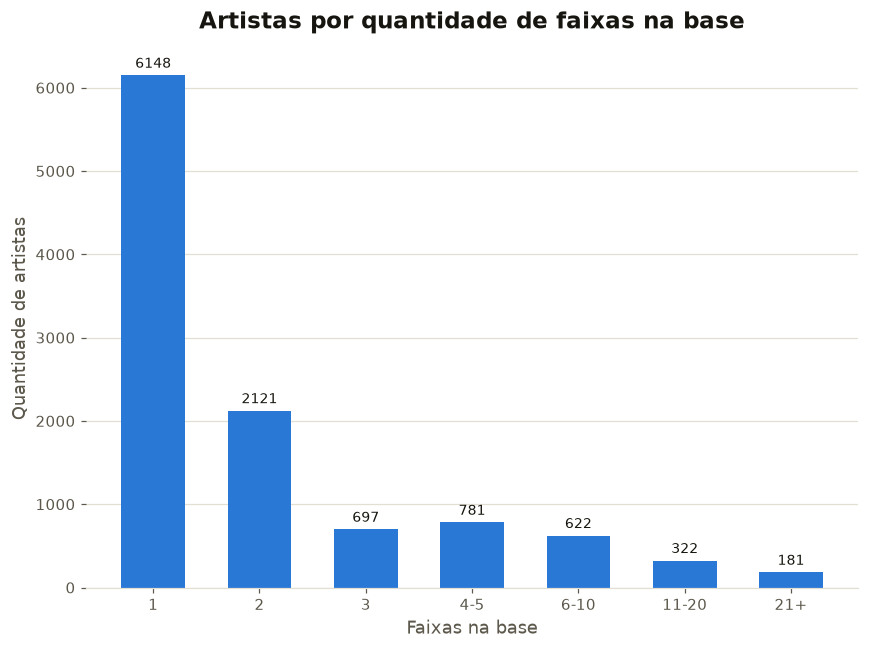

In [4]:
BUCKET_EDGES = [0, 1, 2, 3, 5, 10, 20, 1000]
BUCKET_LABELS = ["1", "2", "3", "4-5", "6-10", "11-20", "21+"]


def bucket_counts(group_sizes: pd.Series) -> pd.Series:
    buckets = pd.cut(group_sizes, bins=BUCKET_EDGES, labels=BUCKET_LABELS)
    return buckets.value_counts().reindex(BUCKET_LABELS, fill_value=0)


def plot_distribution(counts: pd.Series, title: str, ylabel: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 6), dpi=110)
    ax.bar(counts.index.astype(str), counts.values, color=ACCENT, width=0.6)

    max_value = max(counts.values.max(), 1)
    for i, value in enumerate(counts.values):
        ax.text(i, value + max_value * 0.015, str(int(value)), ha="center", fontsize=9, color=INK)

    ax.set_xlabel("Faixas na base", color=INK_SECONDARY, fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=LABEL_SIZE)
    ax.set_title(title, color=INK, fontsize=TITLE_SIZE, fontweight="bold", pad=14)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    apply_style(ax)
    fig.tight_layout()


artist_counts = df.groupby("artists").size()
plot_distribution(bucket_counts(artist_counts), "Artistas por quantidade de faixas na base", "Quantidade de artistas")
plt.show()

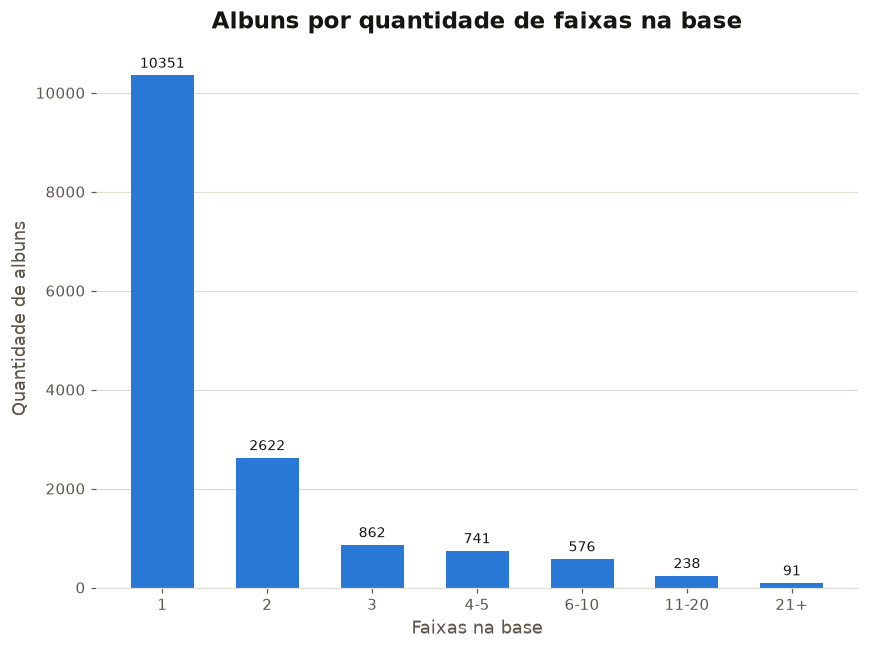

In [5]:
album_counts = df.groupby("album_name").size()
plot_distribution(bucket_counts(album_counts), "Albuns por quantidade de faixas na base", "Quantidade de albuns")
plt.show()

## 4. Faixas presentes em mais de um genero

Mesma faixa (nome + artista) catalogada sob `track_genre` diferentes —
`profile_dataset.py::top_multi_genre_tracks`.

In [6]:
def top_multi_genre_tracks(df: pd.DataFrame, n: int = 15) -> pd.DataFrame:
    grouped = (
        df.groupby(["track_name", "artists"])["track_genre"]
        .nunique()
        .reset_index(name="genre_count")
    )
    multi = grouped[grouped["genre_count"] > 1]
    return multi.sort_values("genre_count", ascending=False, kind="stable").head(n).reset_index(drop=True)


top_multi_genre_tracks(df)

,track_name,artists,genre_count
0,Everything Goes On,Porter Robinson;League of Legends,4
1,Love Is Gone,SLANDER;Dylan Matthew,4
2,A Great Big Sled,The Killers;Toni Halliday,3
3,A feira,O Rappa,3
4,About Me,Koven;ROY KNOX,3
5,All Right Now,Free,3
6,All That Really Matters,ILLENIUM;Teddy Swims,3
7,All We Know,The Chainsmokers;Phoebe Ryan,3
8,Alone,Marshmello,3
9,Arise,Sepultura,3


## 5. Resumo por genero

Contagem de faixas e media das colunas numericas por `track_genre` —
`group_occurrences.py::build_genre_summary`. Essa tabela alimenta os
graficos de popularidade, energia/dancabilidade e mode a seguir.

In [7]:
def build_genre_summary(df: pd.DataFrame) -> pd.DataFrame:
    numeric_columns = df.select_dtypes(include="number").columns.drop("Unnamed: 0", errors="ignore")
    summary = df.groupby("track_genre")[numeric_columns].mean(numeric_only=True)
    summary.insert(0, "contagem", df.groupby("track_genre").size())
    return summary.sort_values("contagem", ascending=False, kind="stable").reset_index()


genre_summary = build_genre_summary(df)
genre_summary.head()

,track_genre,contagem,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,acoustic,1000,42.483,214896.957,0.549593,0.435368,5.045,-9.447843,0.816,0.043247,0.566816,0.038336,0.153244,0.424023,119.010624,3.885
1,afrobeat,1000,24.399,248412.791,0.669580,0.702812,5.551,-7.789353,0.511,0.086579,0.270860,0.253483,0.184596,0.698619,119.213337,3.946
2,alt-rock,1000,33.943,235455.907,0.534493,0.754173,5.738,-6.191489,0.641,0.055071,0.122162,0.054097,0.210249,0.518260,124.634404,3.939
3,alternative,1000,24.337,222016.180,0.559927,0.720030,5.567,-6.078777,0.606,0.070101,0.147820,0.038159,0.201376,0.495570,122.232394,3.942
4,ambient,1000,44.191,237059.038,0.367867,0.237162,4.945,-18.601365,0.620,0.041562,0.776790,0.676221,0.129283,0.167498,111.113129,3.653


## 6. Popularidade media por genero

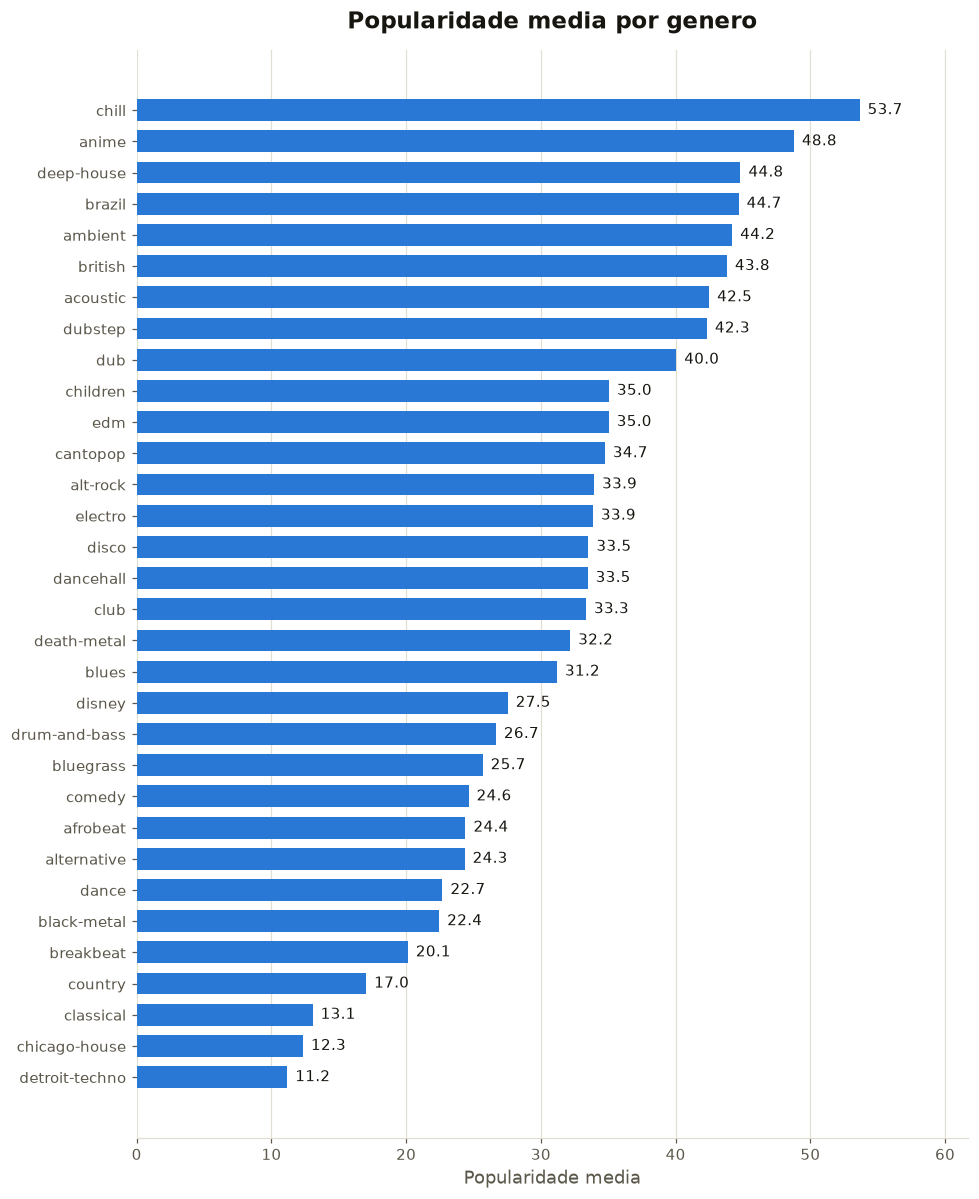

In [8]:
def plot_popularity_bars(df: pd.DataFrame) -> None:
    ranked = df.sort_values("popularity", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 11), dpi=110)
    bars = ax.barh(ranked["track_genre"], ranked["popularity"], color=ACCENT, height=0.7)

    for bar, value in zip(bars, ranked["popularity"]):
        ax.text(bar.get_width() + 0.6, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", va="center", fontsize=TICK_SIZE, color=INK)

    ax.set_xlim(0, ranked["popularity"].max() * 1.15)
    ax.set_xlabel("Popularidade media", color=INK_SECONDARY, fontsize=LABEL_SIZE)
    ax.set_title("Popularidade media por genero", color=INK, fontsize=TITLE_SIZE, fontweight="bold", pad=14)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    apply_style(ax)
    fig.tight_layout()


plot_popularity_bars(genre_summary)
plt.show()

## 7. Energia x Dancabilidade por genero

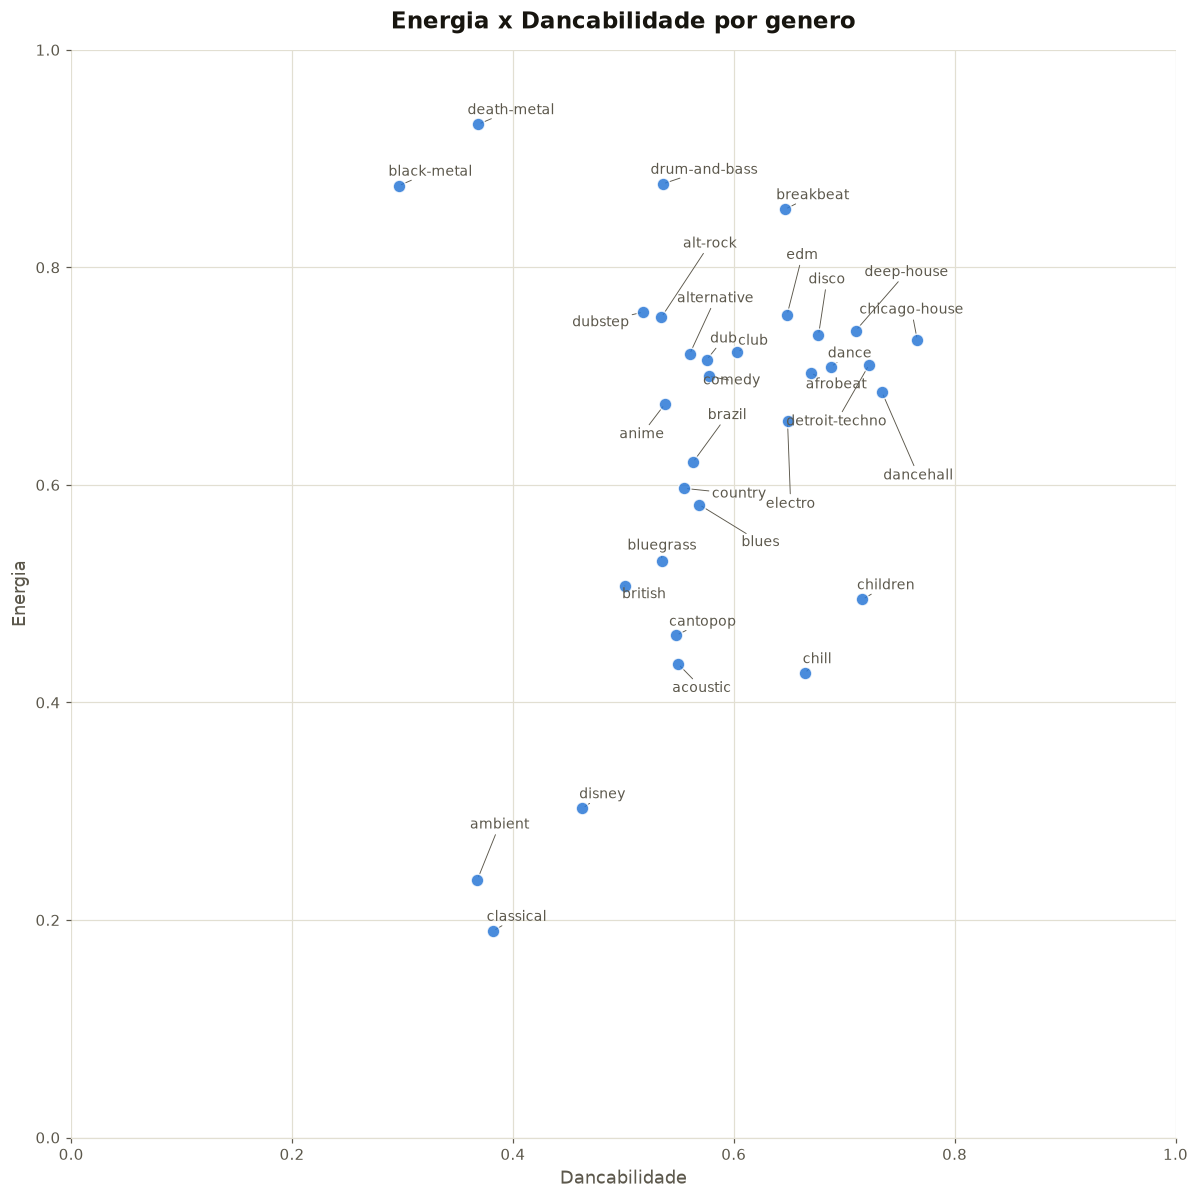

In [9]:
def plot_energy_vs_dance(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(11, 11), dpi=110)
    ax.scatter(df["danceability"], df["energy"], s=70, color=ACCENT, alpha=0.85, edgecolors="white", linewidths=1, zorder=3)

    texts = [
        ax.text(row["danceability"], row["energy"], row["track_genre"], fontsize=TICK_SIZE - 1, color=INK_SECONDARY)
        for _, row in df.iterrows()
    ]
    adjust_text(
        texts,
        x=df["danceability"].to_numpy(),
        y=df["energy"].to_numpy(),
        ax=ax,
        expand=(1.4, 1.7),
        force_text=(1.2, 1.6),
        force_static=(0.5, 0.7),
        max_move=(400, 400),
        time_lim=25,
        arrowprops=dict(arrowstyle="-", color=INK_SECONDARY, lw=0.6),
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Dancabilidade", color=INK_SECONDARY, fontsize=LABEL_SIZE)
    ax.set_ylabel("Energia", color=INK_SECONDARY, fontsize=LABEL_SIZE)
    ax.set_title("Energia x Dancabilidade por genero", color=INK, fontsize=TITLE_SIZE, fontweight="bold", pad=14)
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    apply_style(ax)
    fig.tight_layout()


plot_energy_vs_dance(genre_summary)
plt.show()

## 8. Escala (mode) por genero

`mode` 1 = escala maior, `mode` 0 = escala menor.

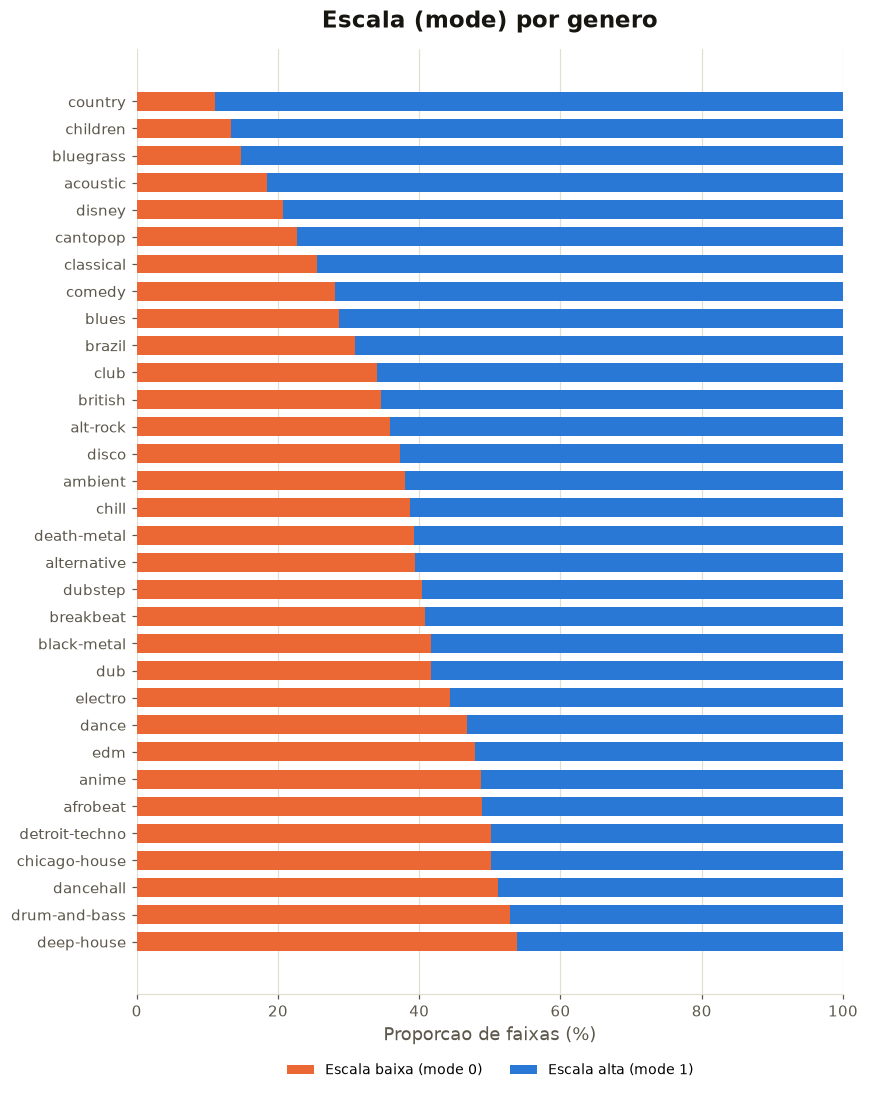

In [10]:
def plot_genre_mode(df: pd.DataFrame) -> None:
    share = df.groupby("track_genre")["mode"].mean().sort_values()
    genres = share.index
    mode1_pct = share.values * 100
    mode0_pct = 100 - mode1_pct

    fig, ax = plt.subplots(figsize=(8, 10), dpi=110)
    ax.barh(genres, mode0_pct, color="#eb6834", height=0.7, label="Escala baixa (mode 0)")
    ax.barh(genres, mode1_pct, left=mode0_pct, color="#2a78d6", height=0.7, label="Escala alta (mode 1)")

    ax.set_xlim(0, 100)
    ax.set_xlabel("Proporcao de faixas (%)", color=INK_SECONDARY, fontsize=LABEL_SIZE)
    ax.set_title("Escala (mode) por genero", color=INK, fontsize=TITLE_SIZE, fontweight="bold", pad=14)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    apply_style(ax)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=2, frameon=False, fontsize=9)
    fig.tight_layout()


plot_genre_mode(df)
plt.show()

## 9. Popularidade x ocorrencias do artista

Popularidade media das faixas em funcao de quantas faixas o artista tem na
base (proxy de volume de catalogo).

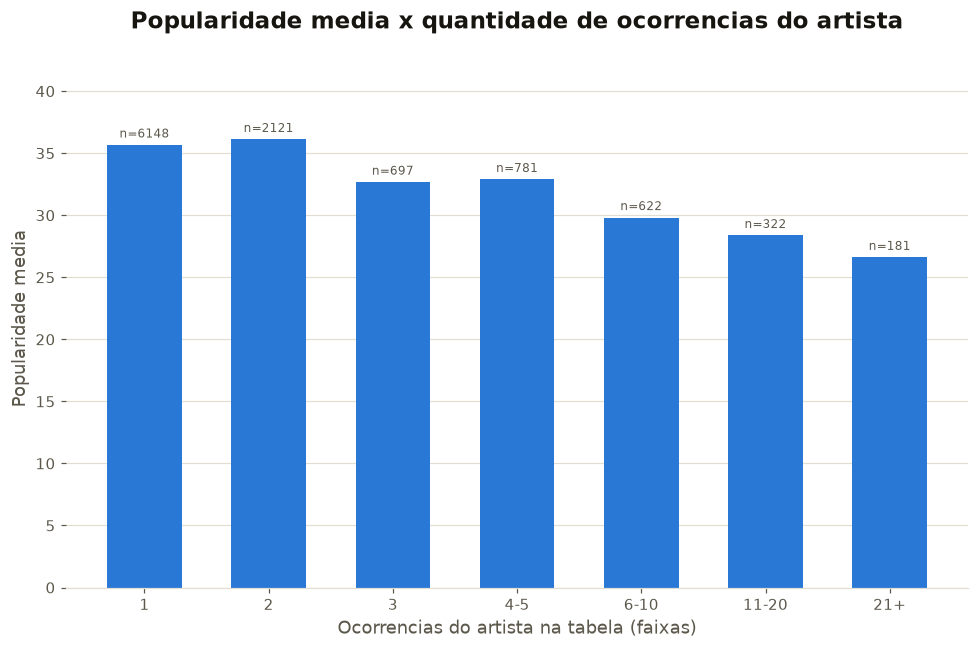

In [11]:
def build_popularity_summary(df: pd.DataFrame) -> pd.DataFrame:
    per_artist = df.groupby("artists")["popularity"].agg(["mean", "count"]).reset_index()
    per_artist["bucket"] = pd.cut(per_artist["count"], bins=BUCKET_EDGES, labels=BUCKET_LABELS)
    summary = per_artist.groupby("bucket", observed=True).agg(artistas=("mean", "size"), popularidade_media=("mean", "mean"))
    return summary.reindex(BUCKET_LABELS)


def plot_popularity_vs_occurrences(summary: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(9, 6), dpi=110)
    bars = ax.bar(summary.index, summary["popularidade_media"], color=ACCENT, width=0.6)

    for bar, artistas in zip(bars, summary["artistas"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6, f"n={artistas}", ha="center", fontsize=8, color=INK_SECONDARY)

    ax.set_ylim(0, summary["popularidade_media"].max() * 1.2)
    ax.set_xlabel("Ocorrencias do artista na tabela (faixas)", color=INK_SECONDARY, fontsize=LABEL_SIZE)
    ax.set_ylabel("Popularidade media", color=INK_SECONDARY, fontsize=LABEL_SIZE)
    ax.set_title("Popularidade media x quantidade de ocorrencias do artista", color=INK, fontsize=TITLE_SIZE, fontweight="bold", pad=14)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    apply_style(ax)
    fig.tight_layout()


popularity_summary = build_popularity_summary(df)
plot_popularity_vs_occurrences(popularity_summary)
plt.show()

## 10. Correlacoes entre popularidade, duracao e features de audio

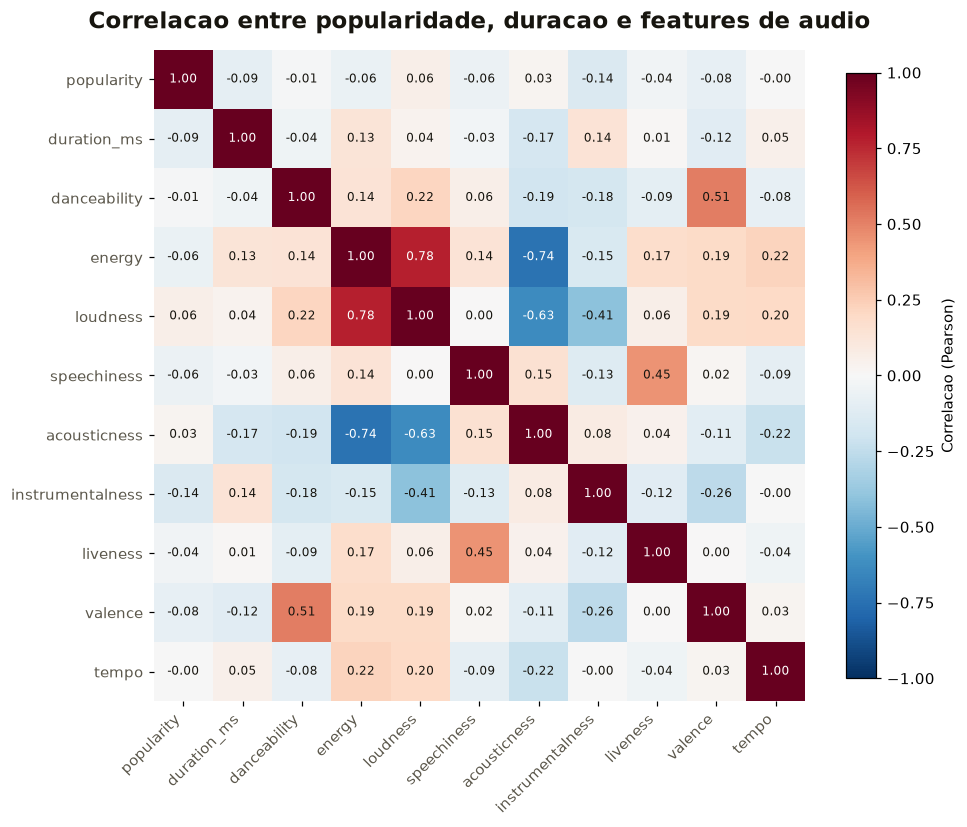

,column_a,column_b,correlation
0,energy,loudness,0.775190
1,energy,acousticness,-0.741718
2,loudness,acousticness,-0.630325
3,danceability,valence,0.511631
4,speechiness,liveness,0.448283
5,loudness,instrumentalness,-0.413360
6,instrumentalness,valence,-0.257872
7,acousticness,tempo,-0.223982
8,energy,tempo,0.223105
9,danceability,loudness,0.216674


In [12]:
CORRELATION_COLUMNS = [
    "popularity", "duration_ms", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo",
]


def top_pairs(corr: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    columns = list(corr.columns)
    rows = [
        {"column_a": col_a, "column_b": col_b, "correlation": corr.loc[col_a, col_b]}
        for i, col_a in enumerate(columns)
        for col_b in columns[i + 1:]
    ]
    result = pd.DataFrame(rows)
    result["abs_correlation"] = result["correlation"].abs()
    result = result.sort_values("abs_correlation", ascending=False, kind="stable").drop(columns="abs_correlation")
    return result.head(n).reset_index(drop=True)


def plot_heatmap(corr: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(9, 8), dpi=110)
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

    columns = list(corr.columns)
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right", fontsize=TICK_SIZE, color=INK_SECONDARY)
    ax.set_yticklabels(columns, fontsize=TICK_SIZE, color=INK_SECONDARY)

    for i in range(len(columns)):
        for j in range(len(columns)):
            value = corr.values[i, j]
            text_color = "white" if abs(value) > 0.6 else INK
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color=text_color)

    ax.set_title("Correlacao entre popularidade, duracao e features de audio", color=INK, fontsize=TITLE_SIZE, fontweight="bold", pad=14)
    fig.colorbar(im, ax=ax, shrink=0.8, label="Correlacao (Pearson)")
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.tight_layout()


corr = df[CORRELATION_COLUMNS].corr()
plot_heatmap(corr)
plt.show()
top_pairs(corr)

## Proximos passos

Este notebook cobre a etapa de EDA. Para gerar os artefatos versionados
(PNGs/CSVs que o site em `site/` consome), use os scripts `.py` listados no
`README.md` — eles sao a fonte reprodutivel usada em CI. As proximas etapas
do roadmap (modelagem de recomendacao, avaliacao com dataset
complementar) devem ganhar suas proprias secoes aqui conforme forem
implementadas.